In [1]:
# Ejecuta esta celda si recibes un error de ModuleNotFoundError (TensorFlow, etc.)
import sys
!{sys.executable} -m pip install tensorflow scikit-learn matplotlib numpy opencv-python

'c:\Program' is not recognized as an internal or external command,
operable program or batch file.


# Enrique Sucre Dogs vs Cats
# Sistema de Clasificación de Imágenes: Perros vs Gatos

Este notebook implementa un clasificador de redes neuronales convolucionales (CNN) para gatos y perros basándose en la arquitectura VGG16. El conjunto de datos consta de 25,000 imágenes proporcionadas por Petfinder.com y Microsoft.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split

base_path = '../dogs-vs-cats/train/'
img_width, img_height = 200, 200

def load_dataset(path):
    images = []
    labels = []
    files = os.listdir(path)
    
    print(f"Cargando {len(files)} imágenes...")
    for i, file in enumerate(files):
        if i % 5000 == 0: print(f"Procesadas {i} imágenes...")
        label = 1 if 'dog' in file else 0
        
        img = load_img(os.path.join(path, file), target_size=(img_width, img_height))
        img_array = img_to_array(img)
        
        images.append(img_array)
        labels.append(label)
    
    return np.array(images), np.array(labels)

photos, labels = load_dataset(base_path)
print("Carga finalizada. Forma de los datos:", photos.shape)

Cargando 25000 imágenes...
Procesadas 0 imágenes...
Procesadas 5000 imágenes...
Procesadas 10000 imágenes...
Procesadas 15000 imágenes...
Procesadas 20000 imágenes...
Carga finalizada. Forma de los datos: (25000, 200, 200, 3)


### Paso 2: Visualiza la información de entrada

Vamos a visualizar las primeras nueve fotos de perros y de gatos.

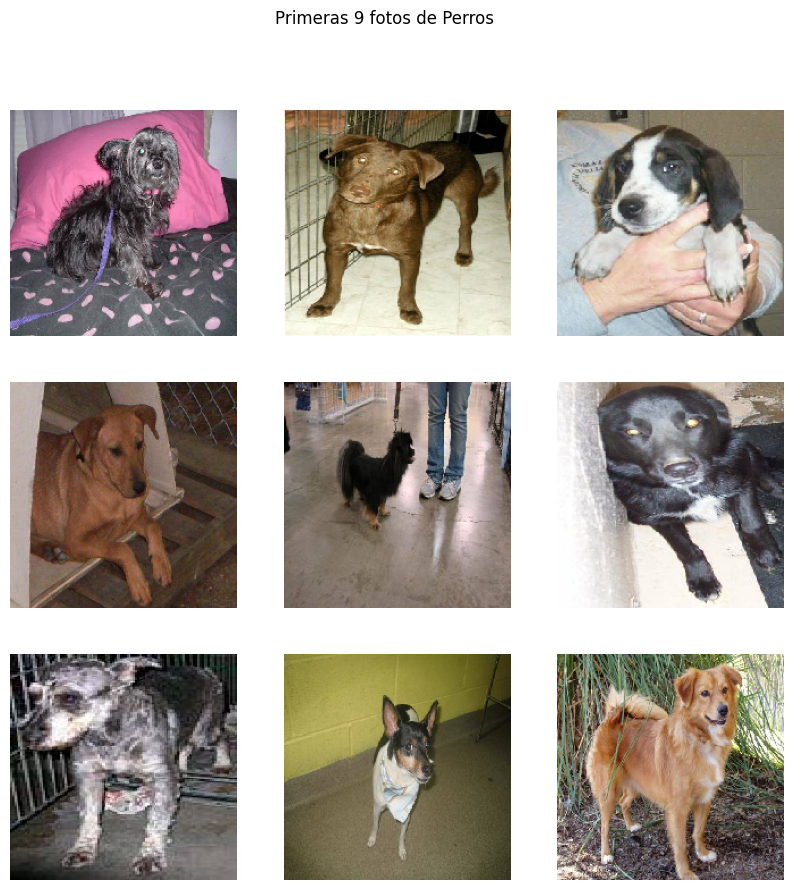

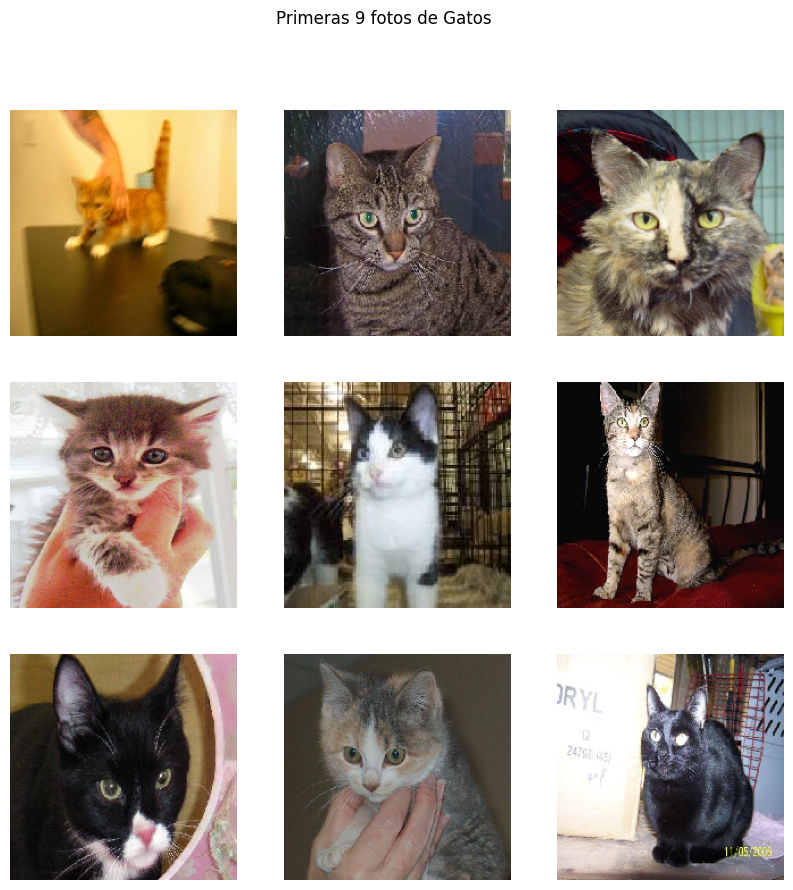

In [3]:
def plot_images(images, labels, title, class_idx):
    idx = np.where(labels == class_idx)[0][:9]
    plt.figure(figsize=(10, 10))
    for i, img_idx in enumerate(idx):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[img_idx].astype('uint8'))
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

plot_images(photos, labels, "Primeras 9 fotos de Perros", 1)
plot_images(photos, labels, "Primeras 9 fotos de Gatos", 0)

Normalización y creación de generadores para entrenamiento y prueba.

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

photos = photos / 255.0
X_train, X_test, y_train, y_test = train_test_split(photos, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator()
trdata = datagen.flow(X_train, y_train, batch_size=64)
tsdata = datagen.flow(X_test, y_test, batch_size=64)

### Paso 3: Construye una RNA (Arquitectura VGG16)

In [5]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(input_shape = (200,200,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))

model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))

model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))

model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))

model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))

model.add(Flatten())
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 2, activation = "softmax"))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\Farmatodo Kike\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    75,501,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,005,762 (408.19 MB)

 Trainable params: 107,005,762 (408.19 MB)

 Non-trainable params: 0 (0.00 B)

### Paso 4: Optimización y Entrenamiento

In [6]:
checkpoint = ModelCheckpoint("../models/vgg16_best.keras", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
early = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=20, verbose=1, mode='max')

hist = model.fit(trdata, validation_data=tsdata, epochs=100, callbacks=[checkpoint, early])

Epoch 1/100
 32/313 ━━━━━━━━━━━━━━━━━━━━ 1:11:19 15s/step - accuracy: 0.4771 - loss: 1.1391

KeyboardInterrupt: 

### Paso 5: Guarda el modelo y realiza predicciones

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("../models/vgg16_best.keras")
results = best_model.evaluate(X_test, y_test)
print(f"Pérdida en Test: {results[0]}, Precisión en Test: {results[1]}")

preds = best_model.predict(X_test[:5])
for i, p in enumerate(preds):
    label = "Perro" if np.argmax(p) == 1 else "Gato"
    print(f"Imagen {i}: Predicción: {label}")